In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ( classification_report ,
                             accuracy_score,
                              recall_score,
                              f1_score,
                              balanced_accuracy_score,
                              confusion_matrix,
                              roc_curve,
                              roc_auc_score)

    

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from plotly.subplots import make_subplots

In [5]:
df= pd.read_csv("data.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df.describe(include="all").T.style.background_gradient(cmap='YlGnBu', axis=0)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,nan,nan,nan,nan,nan,nan,nan
gender,7043,2,Male,3555,nan,nan,nan,nan,nan,nan,nan
SeniorCitizen,7043.000000,nan,nan,nan,0.162147,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
Partner,7043,2,No,3641,nan,nan,nan,nan,nan,nan,nan
Dependents,7043,2,No,4933,nan,nan,nan,nan,nan,nan,nan
tenure,7043.000000,nan,nan,nan,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
PhoneService,7043,2,Yes,6361,nan,nan,nan,nan,nan,nan,nan
MultipleLines,7043,3,No,3390,nan,nan,nan,nan,nan,nan,nan
InternetService,7043,3,Fiber optic,3096,nan,nan,nan,nan,nan,nan,nan
OnlineSecurity,7043,3,No,3498,nan,nan,nan,nan,nan,nan,nan


In [10]:
g_labels=['Male','Female']
c_labels= ['No','Yes']

In [11]:
c_labels= ['No','Yes']
# create subplots use 'domain' type for Pie subplot 
fig= make_subplots(rows=1,cols=2,specs=[[{'type':'domain'},{'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels,values=df['gender'].value_counts(),name='Gender',hole=0.4,),1,1)
fig.add_trace(go.Pie(labels=c_labels,values=df['Churn'].value_counts(),name='Gender',hole=0.4,),1,2)
fig.update_layout(
    title_text="Gender and Churn Distributions",
    # add anotations in the center of donut charts 
    annotations=[dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False),
                 dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)])
fig.show()


In [15]:
df.groupby("gender")["Churn"].value_counts()
gender  Churn
Female  No       2549
        Yes       939
Male    No       2625
        Yes       930
Name: count, dtype: int64
# Define data
labels = ["Churn: Yes", "Churn: No", "F_Yes", "M_Yes", "F_No", "M_No"]
parents = ["", "", "Churn: Yes", "Churn: Yes", "Churn: No", "Churn: No"]
values = [1869, 5163, 939, 930, 2544, 2619]

# --- CORRECT COLOR MAPPING ---
# Create a dictionary where each data label maps to a specific color
# Use logic: similar parent (No/Yes) = similar outer color family
color_map = {
    # Innermost rings (Parent categories)
    "Churn: No":"firebrick",   # Total 'No Churn' (blue family)
    "Churn: Yes":"royalblue", # Total 'Yes Churn' (red family)

    # Outer rings (Children) - linked to parent colors
    # No Churn branch (royalblue shades)
    "F_No": "tomato" , 
    "M_No": "salmon",

    # Yes Churn branch (firebrick shades)
    "F_Yes": "deepskyblue",
    "M_Yes":"skyblue" 
}

# --- CREATE CHART ---
fig = go.Figure(go.Sunburst(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    
    # Customizing what text displays inside the slices
    textinfo="label+percent parent", 
    
    # Apply the correct color sequence to the data
    marker=dict(colors=colors_array),
))

# Define layout with a clean template
fig.update_layout(
    title="Churn Distribution w.r.t Gender",
    width=600,
    height=600,
    template="plotly_white", # Provides a clean white background
)

fig.show()

SyntaxError: invalid syntax (3618683873.py, line 2)

In [16]:
fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [17]:
# Plotly Express automatically counts rows and aligns labels perfectly
fig = px.pie(
    df, 
    names='PaymentMethod', 
    hole=0.3, 
    title="<b>Payment Method Distribution</b>"
)

fig.show()

In [18]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [19]:
df["InternetService"].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [22]:
array(['DSL', 'Fiber optic', 'No'], dtype=object)
df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()


NameError: name 'array' is not defined

In [ ]:
df[df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()

In [23]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.show()

In [24]:
#color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [25]:
# 1. Prepare data by resetting index so columns are accessible
plot_df = df.groupby(["Dependents", "Contract"])["Churn"].value_counts(normalize=True).rename("Percentage").reset_index()
plot_df["Percentage"] *= 100  # Convert fractions to clean percentages

# 2. Build the clustered bar chart
fig = px.bar(
    plot_df,
    x="Contract",
    y="Percentage",
    color="Churn",
    facet_col="Dependents",
    barmode="group",
    title="<b>Churn Rates by Contract Type and Dependent Status</b>",
    labels={"Percentage": "Percentage (%)"},
    color_discrete_map={"Yes": "firebrick", "No": "royalblue"} # Match your color theme
)

fig.update_layout(yaxis_ticksuffix="%")
fig.show()

In [26]:
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Chrun distribution w.r.t. Partners</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [27]:
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Chrun distribution w.r.t. Senior Citizen</b>")
fig.show()

In [28]:
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [29]:
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Chrun distribution w.r.t. Paperless Billing</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [30]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Chrun distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [31]:
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Chrun distribution w.r.t. Phone Service</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

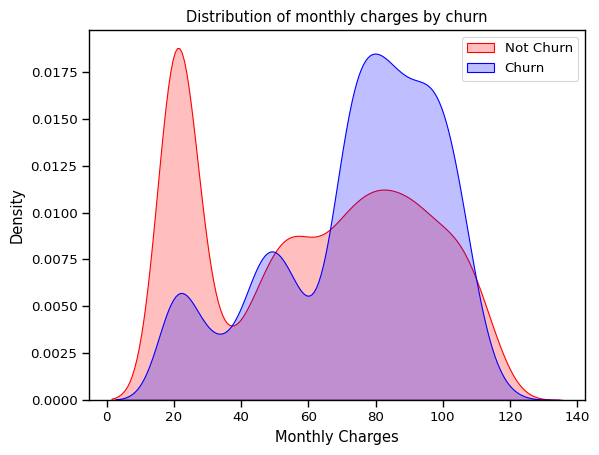

In [32]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", fill=True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", fill=True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');

In [33]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

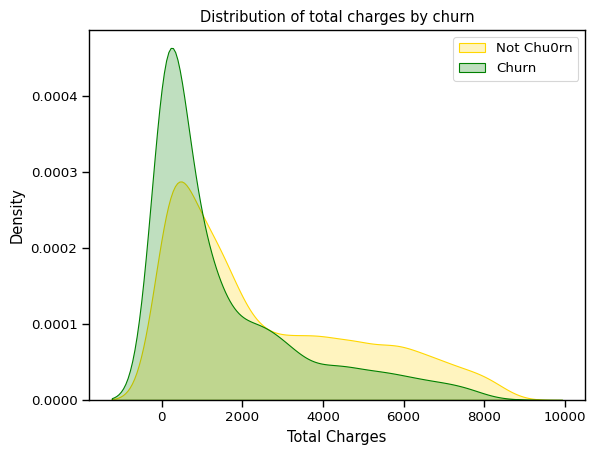

In [34]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", fill=True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", fill=True);
ax.legend(["Not Chu0rn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');

In [35]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

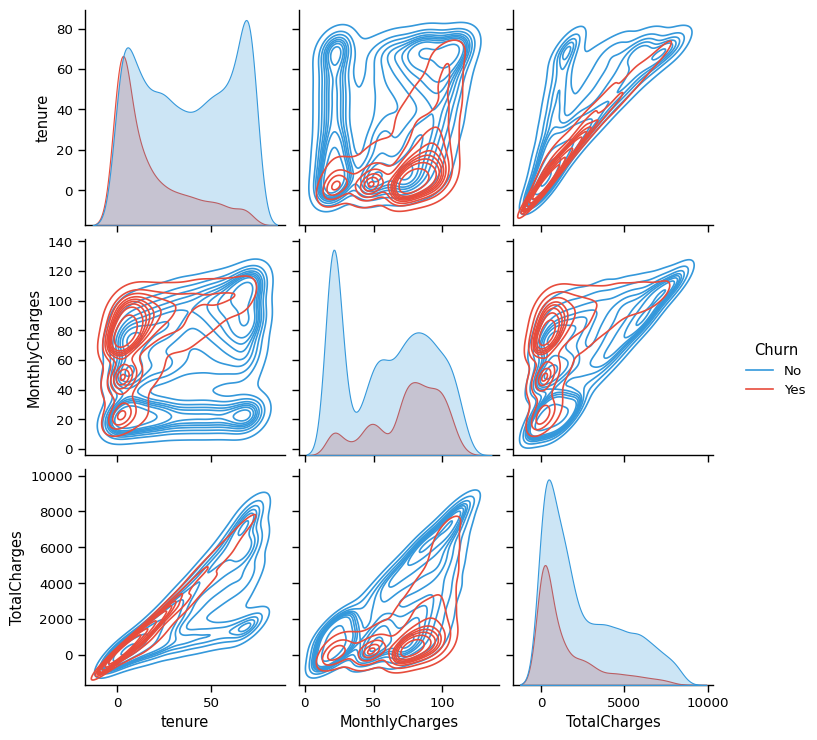

In [37]:
# Select only numeric columns + your categorical target
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

# Run pairplot with KDE curves instead of scatterplots
sns.pairplot(
    df[numeric_cols], 
    hue='Churn', 
    kind='kde', 
    palette={'Yes': '#e74c3c', 'No': '#3498db'}
)
plt.show()

In [38]:
plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vma

_IncompleteInputError: incomplete input (3091893700.py, line 7)